<a href="https://colab.research.google.com/github/LoshithaAI/ML-Assignment/blob/thuiyadura-lr-ms26923956/notebooks/logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone -b thuiyadura-lr-ms26923956 https://github.com/LoshithaAI/ML-Assignment.git

Cloning into 'ML-Assignment'...
remote: Enumerating objects: 29, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 29 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (29/29), 110.72 KiB | 1003.00 KiB/s, done.
Resolving deltas: 100% (2/2), done.


In [2]:
!ls ML-Assignment

data  notebooks  README.md


# Predicting Student Dropout and Academic Success — Logistic Regression
**Fundamentals of Machine Learning – Programming Assignment**

| | |
|---|---|
| **Member** | `Thuiyadura L.R` (`MS26923956`) |
| **Algorithm** | Logistic Regression (multinomial) |
| **Teammate's algorithm** | Random Forest (`random_forest.ipynb`) |
| **Learning type** | Supervised learning – multi-class classification |

**Notebook map (matches the marking rubric)**

| Section | Rubric item |
|---|---|
| 1. Setup | – |
| 2. Dataset description | #1 Dataset selection, #2 Description |
| 3. Data preprocessing | #3 Preprocessing |
| 4. Algorithm background and justification | #4 Application of algorithm |
| 5. Model implementation (baseline + tuning) | #4, #5 Implementation |
| 6. Results on the test set | #6 Results |
| 7. Improvement experiments, critical analysis, future work | #7 Discussion |
| 8. Individual contribution and viva notes | #8, #9 |

In [3]:
# --- Libraries -------------------------------------------------------------
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [4]:
# --- Load the dataset ------------------------------------------------------
import os
GITHUB_RAW_URL = "https://raw.githubusercontent.com/LoshithaAI/ML-Assignment/thuiyadura-lr-ms26923956/data/data.csv"

for path in ["data.csv", "data/data.csv", "../data/data.csv"]:
    if os.path.exists(path):
        DATA_PATH = path
        break
else:
    DATA_PATH = GITHUB_RAW_URL

df = pd.read_csv(DATA_PATH, sep=";")
df.columns = df.columns.str.strip()
print("Loaded from:", DATA_PATH)
print("Shape:", df.shape)

Loaded from: https://raw.githubusercontent.com/LoshithaAI/ML-Assignment/thuiyadura-lr-ms26923956/data/data.csv
Shape: (4424, 37)


## 2. Dataset selection and description  *(Rubric #1 and #2)*

**Dataset:** *Predict Students' Dropout and Academic Success*
**Source (UCI Machine Learning Repository):** https://archive.ics.uci.edu/dataset/697
**License:** CC BY 4.0 &nbsp;|&nbsp; **Citation:** `Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021). Predict Students' Dropout and Academic Success [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89.`

**Context.** The data comes from a Portuguese higher-education institution and combines information known at enrollment
(demographics, socioeconomic background, academic path), the student's academic performance at the end of the 1st and 2nd
semesters, and national macroeconomic indicators. It was created to identify students at risk of dropping out so that
the institution can support them early. Each row is one student enrolled in an undergraduate programme
(e.g. agronomy, design, education, nursing, journalism, management, social service, technologies).

**Why it is a suitable dataset**
- Real-world, published online, and hosted on UCI (a credible public repository).
- Not a standard tutorial dataset (unlike Iris/Titanic), and reasonably complex: **4,424 rows, 36 features, 3 classes**.
- Mixed feature types (categorical codes, binary flags, continuous grades) and **imbalanced classes**, which makes the evaluation interesting.

**Target variable:** `Target` – `Dropout`, `Enrolled` or `Graduate` (status at the end of the normal course duration).

**Attributes (36 features + target)**

| Group | Attributes | Type |
|---|---|---|
| Demographic | Marital status, Nacionality, Gender, Age at enrollment, International, Displaced | Categorical code / binary / numeric |
| Application | Application mode, Application order, Course, Daytime/evening attendance | Categorical code / ordinal / binary |
| Previous education | Previous qualification, Previous qualification (grade), Admission grade | Categorical code / numeric |
| Family background | Mother's qualification, Father's qualification, Mother's occupation, Father's occupation | Categorical code |
| Financial / special | Educational special needs, Debtor, Tuition fees up to date, Scholarship holder | Binary |
| 1st-semester performance | Curricular units 1st sem (credited, enrolled, evaluations, approved, grade, without evaluations) | Numeric |
| 2nd-semester performance | Curricular units 2nd sem (credited, enrolled, evaluations, approved, grade, without evaluations) | Numeric |
| Macroeconomic | Unemployment rate, Inflation rate, GDP | Numeric |

> The code-valued columns (Marital status, Application mode, Course, Previous qualification, Nacionality, parents'
> qualification and occupation) are **integer labels for categories, not quantities**. The lookup tables are on the UCI page.

In [6]:
display(df.head())
print("Rows, columns:", df.shape)
print("Features:", df.shape[1] - 1, "| Target: Target")

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


Rows, columns: (4424, 37)
Features: 36 | Target: Target


          count  percent
Target                  
Graduate   2209     49.9
Dropout    1421     32.1
Enrolled    794     17.9


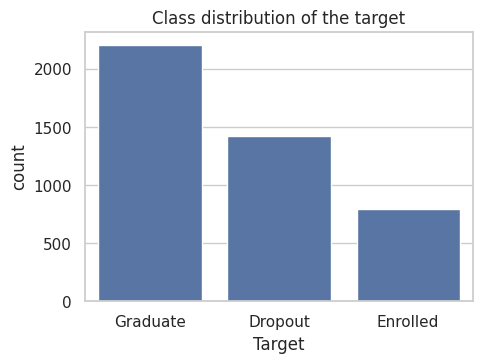

In [7]:
# Class distribution of the target
counts = df["Target"].value_counts()
print(pd.DataFrame({"count": counts, "percent": (counts / len(df) * 100).round(1)}))

plt.figure(figsize=(5, 3.5))
sns.countplot(data=df, x="Target", order=counts.index)
plt.title("Class distribution of the target")
plt.show()

In [8]:
# Summary statistics of the continuous attributes
cat_cols = ["Marital status", "Application mode", "Course", "Previous qualification", "Nacionality",
            "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation"]
binary_cols = [c for c in df.columns if c not in cat_cols + ["Target"] and df[c].nunique() <= 2]
num_cols = [c for c in df.columns if c not in cat_cols + binary_cols + ["Target", "Application order"]]

print("Categorical-code columns :", len(cat_cols))
print("Binary (0/1) columns     :", len(binary_cols))
print("Continuous columns       :", len(num_cols))
df[num_cols].describe().T.round(2)

Categorical-code columns : 9
Binary (0/1) columns     : 8
Continuous columns       : 18


,count,mean,std,min,25%,50%,75%,max
Previous qualification (grade),4424.0,132.61,13.19,95.00,125.00,133.10,140.00,190.00
Admission grade,4424.0,126.98,14.48,95.00,117.90,126.10,134.80,190.00
Age at enrollment,4424.0,23.27,7.59,17.00,19.00,20.00,25.00,70.00
Curricular units 1st sem (credited),4424.0,0.71,2.36,0.00,0.00,0.00,0.00,20.00
Curricular units 1st sem (enrolled),4424.0,6.27,2.48,0.00,5.00,6.00,7.00,26.00
Curricular units 1st sem (evaluations),4424.0,8.30,4.18,0.00,6.00,8.00,10.00,45.00
Curricular units 1st sem (approved),4424.0,4.71,3.09,0.00,3.00,5.00,6.00,26.00
Curricular units 1st sem (grade),4424.0,10.64,4.84,0.00,11.00,12.29,13.40,18.88
Curricular units 1st sem (without evaluations),4424.0,0.14,0.69,0.00,0.00,0.00,0.00,12.00
Curricular units 2nd sem (credited),4424.0,0.54,1.92,0.00,0.00,0.00,0.00,19.00
